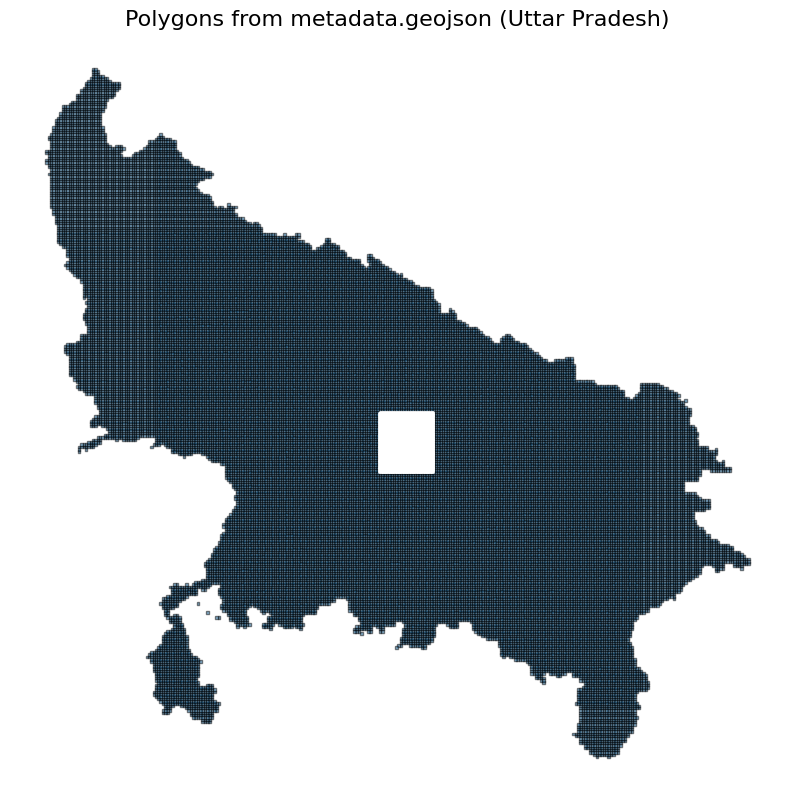

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Path to your geojson file
geojson_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/india/uttar_pradesh/metadata.geojson"
lucknow_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/lucknow_airshed/metadata.geojson"

# Read the geojson file
gdf = gpd.read_file(geojson_path)
gdf_lucknow = gpd.read_file(lucknow_path)
if gdf.crs != gdf_lucknow.crs:
    gdf_lucknow = gdf_lucknow.to_crs(gdf.crs)

# Print info to check if it loaded correctly
# print(gdf.head())

# Plot the polygons
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, edgecolor='black', alpha=0.5)
gdf_lucknow.plot(ax=ax, facecolor='white', edgecolor='white', linewidth=2, alpha=1.0)

# Make plot look nice
ax.set_title('Polygons from metadata.geojson (Uttar Pradesh)', fontsize=16)
ax.set_axis_off()

plt.show()


In [2]:
import geopandas as gpd

# Read Lucknow airshed geojson
lucknow_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/lucknow_airshed/metadata.geojson"
gdf = gpd.read_file(lucknow_path)

# Ensure projected CRS for accurate area/length (use UTM Zone 44N for Lucknow)
gdf_proj = gdf.to_crs(epsg=32644)

# Calculate area (in square km)
gdf_proj['area_sqkm'] = gdf_proj.geometry.area / 1e6  # m² to km²

# Calculate bounding box for height and width
total_bounds = gdf_proj.total_bounds  # [minx, miny, maxx, maxy]
width_m = total_bounds[2] - total_bounds[0]
height_m = total_bounds[3] - total_bounds[1]
width_km = width_m / 1000
height_km = height_m / 1000

# Area results
total_area_sqkm = gdf_proj['area_sqkm'].sum()

print(f"Lucknow airshed total area: {total_area_sqkm:.2f} sq km")
print(f"Width: {width_km:.2f} km")
print(f"Height: {height_km:.2f} km")


Lucknow airshed total area: 4424.28 sq km
Width: 56.87 km
Height: 63.80 km


/tmp/ipykernel_2025205/2084759959.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = gdf_proj.unary_union.centroid


Text(0.5, 1.0, 'Lucknow Airshed (white) inside 100x100km Square (red)')

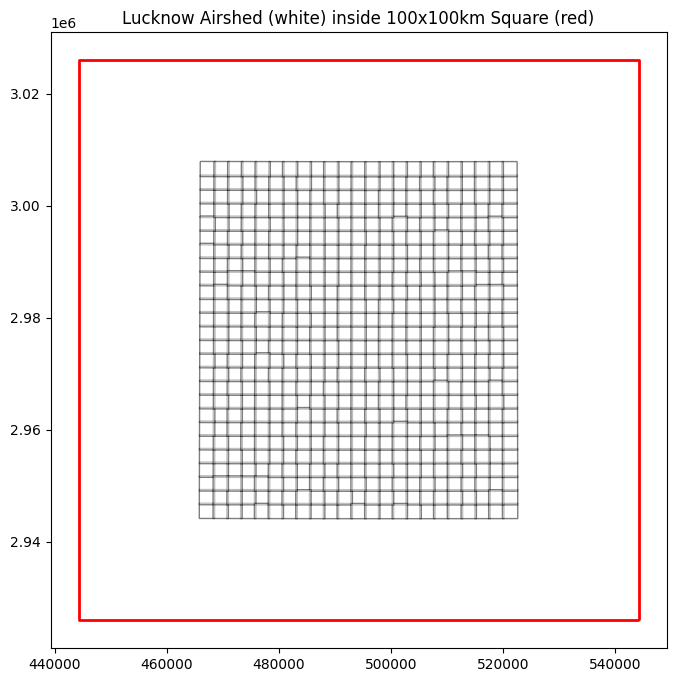

In [3]:
import geopandas as gpd
from shapely.geometry import box

# Read airshed, reproject for metric calculations
gdf = gpd.read_file("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/lucknow_airshed/metadata.geojson")
gdf_proj = gdf.to_crs(epsg=32644)  # UTM zone for Lucknow

# Get centroid of the entire airshed
centroid = gdf_proj.unary_union.centroid

# Define 100 km in meters
half_size = 50_000  # half of 100 km = 50,000 meters

# Create a square (100x100 km) centered at centroid
minx, miny = centroid.x - half_size, centroid.y - half_size
maxx, maxy = centroid.x + half_size, centroid.y + half_size
square_geom = box(minx, miny, maxx, maxy)

# Make a new GeoDataFrame for the square
gdf_square = gpd.GeoDataFrame({'geometry': [square_geom]}, crs=gdf_proj.crs)

# Optional: Save to file or reproject back to WGS84 (lat/lon)
# gdf_square.to_crs(epsg=4326).to_file("lucknow_100x100km.geojson", driver='GeoJSON')

# Plot to verify
ax = gdf_proj.plot(facecolor="white", edgecolor="black", alpha=0.5, figsize=(8,8))
gdf_square.boundary.plot(ax=ax, edgecolor="red", linewidth=2)
ax.set_title("Lucknow Airshed (white) inside 100x100km Square (red)")


In [4]:
# File paths
up_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/regions/shapes/uttar_pradesh.geojson"
lucknow_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/lucknow_airshed/metadata.geojson"
delhi_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/regions/shapes/delhi_ncr_region.geojson"
delhi_airshed_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/delhi_airshed/metadata.geojson"

/tmp/ipykernel_2025205/3048017173.py:21: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = gdf_lucknow_proj.unary_union.centroid
/tmp/ipykernel_2025205/3048017173.py:40: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(["Uttar Pradesh", "Lucknow Airshed", "100x100km Square", "Delhi NCR", "Delhi Airshed"])


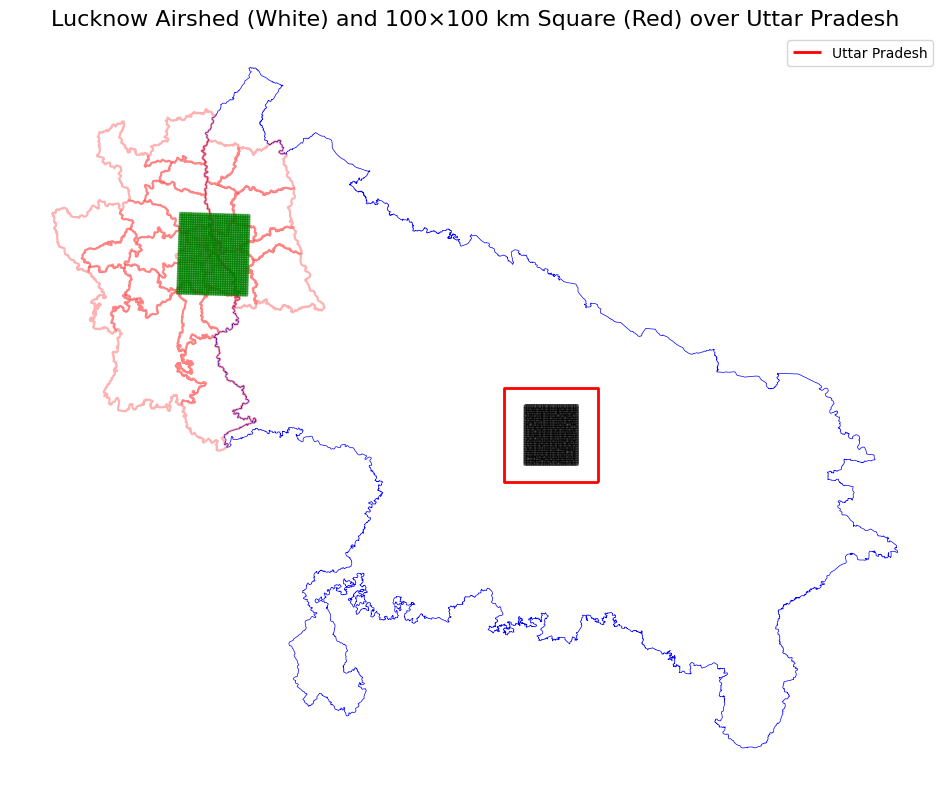

In [14]:
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt



# Read files
gdf_up = gpd.read_file(up_path)
gdf_lucknow = gpd.read_file(lucknow_path)
gdf_delhi = gpd.read_file(delhi_path)
gdf_delhi_airshed = gpd.read_file(delhi_airshed_path)

# Project both to UTM zone 44N for UP/Lucknow
gdf_up_proj = gdf_up.to_crs(epsg=32644)
gdf_lucknow_proj = gdf_lucknow.to_crs(epsg=32644)
gdf_delhi_proj = gdf_delhi.to_crs(epsg=32644)
gdf_delhi_airshed_proj = gdf_delhi_airshed.to_crs(epsg=32644)


# Centroid of the airshed
centroid = gdf_lucknow_proj.unary_union.centroid

# 100x100 km square, centered at centroid
half_size = 50_000  # meters
minx, miny = centroid.x - half_size, centroid.y - half_size
maxx, maxy = centroid.x + half_size, centroid.y + half_size
square_geom = box(minx, miny, maxx, maxy)
gdf_square = gpd.GeoDataFrame({'geometry': [square_geom]}, crs=gdf_lucknow_proj.crs)
gdf_square.to_file("lucknow_100x100km.geojson", driver='GeoJSON')
# PLOT
fig, ax = plt.subplots(figsize=(12, 12))
gdf_up_proj.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=0.5, label='Uttar Pradesh')
gdf_lucknow_proj.plot(ax=ax, facecolor='white', edgecolor='black', linewidth=1.5, alpha=0.7, label='Original Lucknow Airshed')
gdf_square.boundary.plot(ax=ax, edgecolor='red', linewidth=2, label='100x100km Airshed')
gdf_delhi_proj.plot(ax=ax, facecolor='white', edgecolor='red', linewidth=1.5, alpha=0.3, label='Delhi NCR')
gdf_delhi_airshed_proj.plot(ax=ax, facecolor='green', edgecolor='green', linewidth=1.0, alpha=0.5, label='Delhi Airshed')

ax.set_axis_off()
ax.set_title('Lucknow Airshed (White) and 100×100 km Square (Red) over Uttar Pradesh', fontsize=16)
plt.legend(["Uttar Pradesh", "Lucknow Airshed", "100x100km Square", "Delhi NCR", "Delhi Airshed"])
plt.show()


In [7]:
up_except_delhi.to_file("uttar_pradesh_except_delhi.geojson", driver='GeoJSON')



/tmp/ipykernel_2025205/4108532263.py:21: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  ncr_union = gdf_ncr_proj.unary_union
/tmp/ipykernel_2025205/4108532263.py:22: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  square_union = gdf_square_proj.unary_union
/tmp/ipykernel_2025205/4108532263.py:34: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  outer_boundary = gdf_up_minus_ncr_square.unary_union.boundary


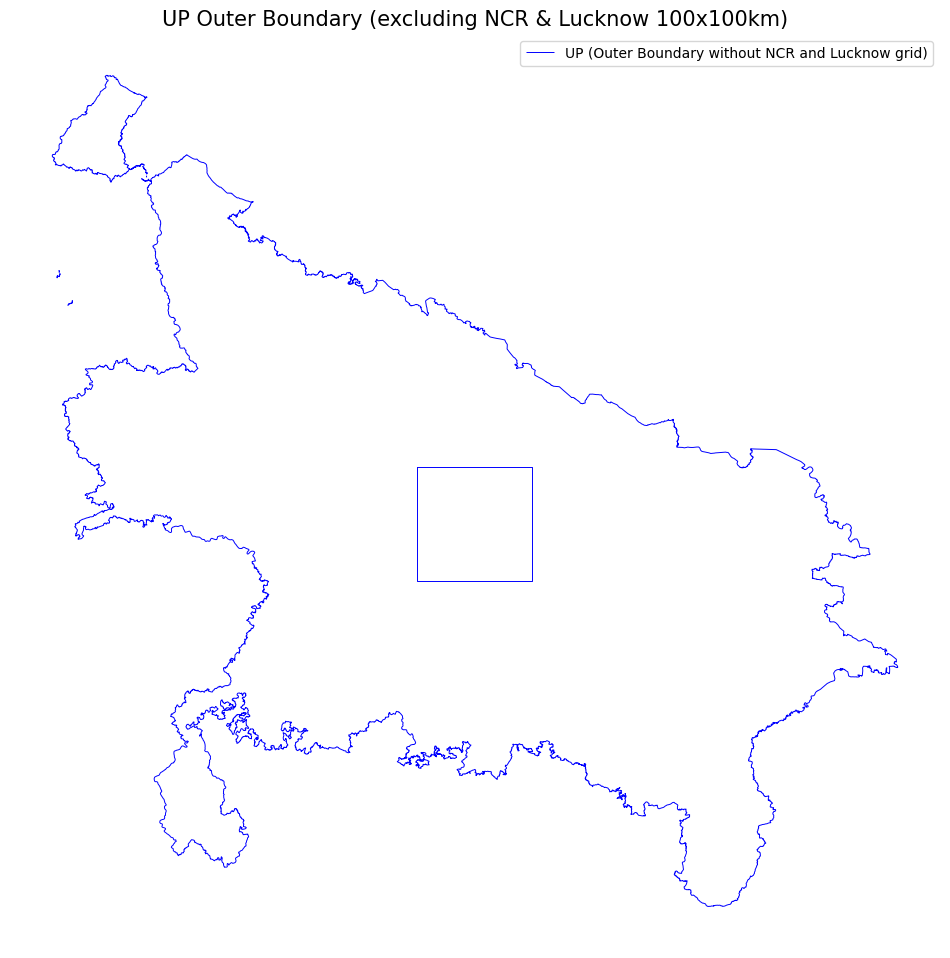

In [60]:
import geopandas as gpd
import matplotlib.pyplot as plt
lucknow_square_path = "lucknow_100x100km.geojson"  # Path to Lucknow 100x100km geojson
# Load UP, NCR, and Lucknow Square polygons
gdf_up = gpd.read_file(up_path)
gdf_ncr = gpd.read_file(delhi_path)
gdf_square = gpd.read_file(lucknow_square_path)  # Path to Lucknow 100x100km geojson

# Reproject all to same projected CRS
target_crs = "EPSG:32644"
gdf_up_proj = gdf_up.to_crs(target_crs)
gdf_ncr_proj = gdf_ncr.to_crs(target_crs)
gdf_square_proj = gdf_square.to_crs(target_crs)

# Clean up geometries (use buffer(0), not large positive values!)
gdf_up_proj['geometry'] = gdf_up_proj['geometry'].buffer(0)
gdf_ncr_proj['geometry'] = gdf_ncr_proj['geometry'].buffer(0.2)
gdf_square_proj['geometry'] = gdf_square_proj['geometry'].buffer(0)

# Create unions
ncr_union = gdf_ncr_proj.unary_union
square_union = gdf_square_proj.unary_union

# Subtract NCR and Lucknow Square from UP
gdf_up_minus_ncr_square = gdf_up_proj.copy()
gdf_up_minus_ncr_square['geometry'] = gdf_up_minus_ncr_square['geometry'].apply(
    lambda x: x.difference(ncr_union).difference(square_union).buffer(0)
)

# Remove empty or tiny geometries (area > 1 sq km)
# gdf_up_minus_ncr_square = gdf_up_minus_ncr_square[gdf_up_minus_ncr_square.area > 1e6]

# Get outer boundary
outer_boundary = gdf_up_minus_ncr_square.unary_union.boundary
boundary_gdf = gpd.GeoDataFrame(geometry=[outer_boundary], crs=gdf_up_minus_ncr_square.crs)
boundary_gdf.to_file("up_outer_boundary_without_ncr_and_lucknow.geojson", driver='GeoJSON')
# Plot
fig, ax = plt.subplots(figsize=(12, 12))
boundary_gdf.plot(ax=ax, color='blue', linewidth=0.7, label='UP (Outer Boundary without NCR and Lucknow grid)')
# gdf_square_proj.boundary.plot(ax=ax, color='red', linewidth=1.2, label='Lucknow 100x100km grid')
# gdf_ncr_proj.boundary.plot(ax=ax, color='black', linewidth=1, label='Delhi NCR')
ax.set_axis_off()
ax.set_title("UP Outer Boundary (excluding NCR & Lucknow 100x100km)", fontsize=15)
plt.legend()
plt.show()


In [27]:
import geopandas as gpd

# File paths
delhi_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/regions/shapes/delhi_ncr_region.geojson"
delhi_airshed_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/delhi_airshed/metadata.geojson"

# Read files
gdf_ncr = gpd.read_file(delhi_path)
gdf_airshed = gpd.read_file(delhi_airshed_path)

# Reproject to common projected CRS for spatial ops
target_crs = "EPSG:32644"
gdf_ncr_proj = gdf_ncr.to_crs(target_crs)
gdf_airshed_proj = gdf_airshed.to_crs(target_crs)

# Clean up geometry
gdf_ncr_proj['geometry'] = gdf_ncr_proj['geometry'].buffer(0)
gdf_airshed_proj['geometry'] = gdf_airshed_proj['geometry'].buffer(0)

# Create union of airshed
airshed_union = gdf_airshed_proj.unary_union

# Subtract airshed from NCR
gdf_ncr_minus_airshed = gdf_ncr_proj.copy()
gdf_ncr_minus_airshed['geometry'] = gdf_ncr_minus_airshed['geometry'].apply(lambda x: x.difference(airshed_union).buffer(0))

# Remove empty or very tiny geometries if any (optional)
gdf_ncr_minus_airshed = gdf_ncr_minus_airshed[gdf_ncr_minus_airshed.area > 1e5]  # 0.1 sq km

# Reproject back to WGS84 for saving
gdf_ncr_minus_airshed = gdf_ncr_minus_airshed.to_crs("EPSG:4326")

# Save to GeoJSON
gdf_ncr_minus_airshed.to_file("delhi_ncr_without_airshed.geojson", driver="GeoJSON")

print("Saved as delhi_ncr_without_airshed.geojson")



/tmp/ipykernel_2025205/3533380608.py:21: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  airshed_union = gdf_airshed_proj.unary_union


Saved as delhi_ncr_without_airshed.geojson


                                            geometry
0  POLYGON ((92814.275 3128659.205, 92886.337 312...
1  POLYGON ((126900.778 3246712.109, 127042.248 3...
2  MULTIPOLYGON (((111271.195 3083158.32, 111307....
3  POLYGON ((204073.282 3179723.237, 204091.957 3...
4  MULTIPOLYGON (((170354.453 3149161.928, 170530...
   x_idx  y_idx        x        y  \
0   5504  22784  8577459  3276394   
1   4928  22784  8574708  3276394   
2   6080  22784  8580211  3276394   
3   6656  22784  8582963  3276394   
4   8960  22784  8593970  3276394   

                                            geometry  
0  POLYGON ((111190.219 3128975.115, 113888.547 3...  
1  POLYGON ((108761.681 3129054.907, 111460.054 3...  
2  POLYGON ((113618.717 3128895.822, 116317.001 3...  
3  POLYGON ((116047.175 3128817.028, 118745.414 3...  
4  POLYGON ((125760.611 3128506.846, 128458.677 3...  


/tmp/ipykernel_2025205/1169894012.py:18: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


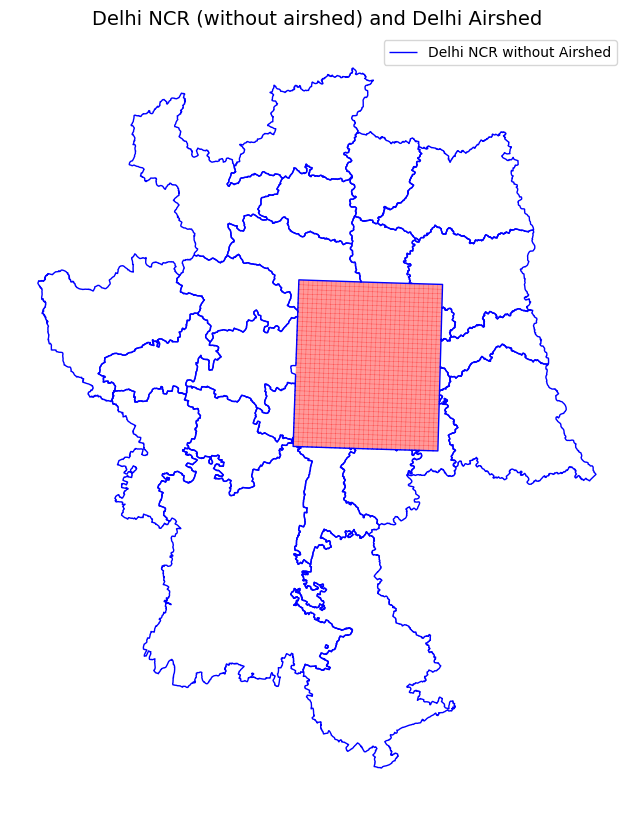

In [46]:
import geopandas as gpd
import matplotlib.pyplot as plt
crs= "EPSG:32644"  # UTM Zone 44N for Lucknow
# Load for plotting (assumes previous code just ran and files exist)
gdf_ncr_minus_airshed = gpd.read_file("delhi_ncr_without_airshed.geojson")
gdf_ncr_minus_airshed = gdf_ncr_minus_airshed.to_crs(crs)  # Ensure same CRS for plotting
print(gdf_ncr_minus_airshed.head())
gdf_airshed = gpd.read_file("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/delhi_airshed/metadata.geojson")
gdf_airshed = gdf_airshed.to_crs(gdf_ncr_minus_airshed.crs)  # Ensure same CRS for plotting
print(gdf_airshed.head())
# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf_ncr_minus_airshed.boundary.plot(ax=ax, color='blue', linewidth=1, label="Delhi NCR without Airshed")
gdf_airshed.plot(ax=ax, color='red', alpha=0.4, label="Delhi Airshed")

ax.set_title("Delhi NCR (without airshed) and Delhi Airshed", fontsize=14)
ax.set_axis_off()
plt.legend()
plt.show()


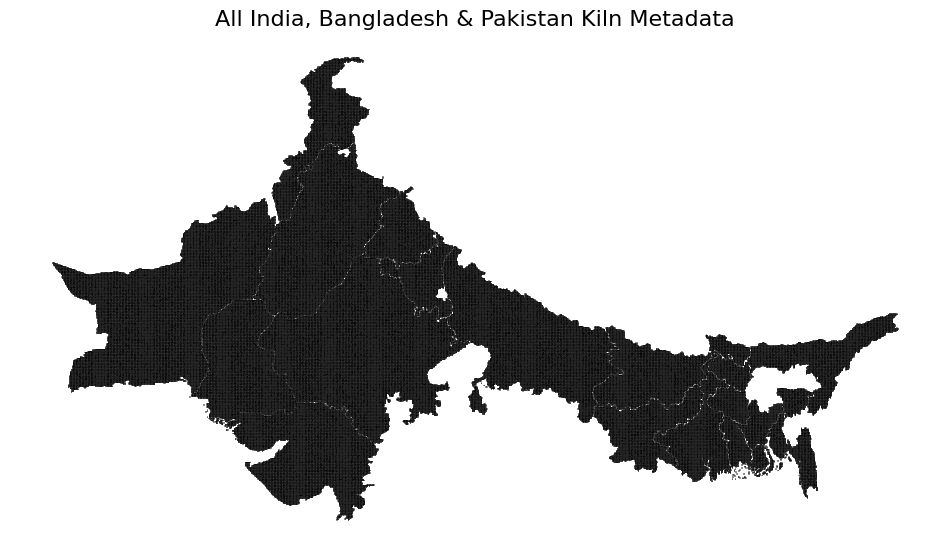

In [47]:
import geopandas as gpd
import matplotlib.pyplot as plt

metadata_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/india_bangladesh_pakisthan_images/metadata_all.geojson"

# Read the GeoJSON
gdf = gpd.read_file(metadata_path)

# Plot
fig, ax = plt.subplots(figsize=(12, 12))
gdf.plot(ax=ax, edgecolor='black', facecolor='lightgrey', linewidth=0.5, alpha=0.6)

ax.set_title("All India, Bangladesh & Pakistan Kiln Metadata", fontsize=16)
ax.set_axis_off()
plt.show()


Selected 1764 features inside NCR minus airshed region.


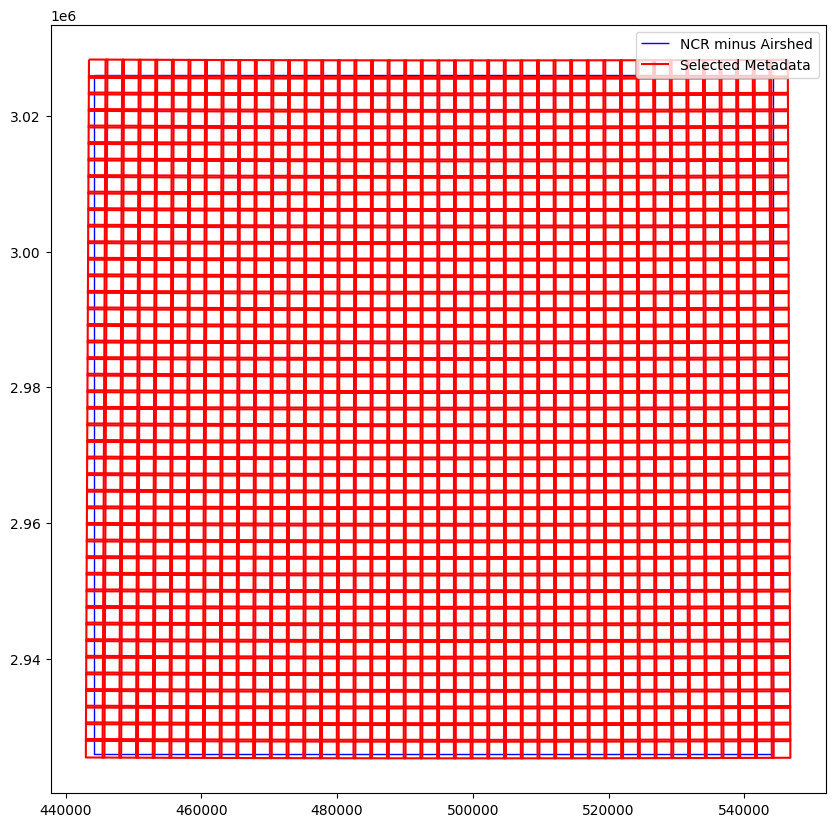

In [72]:
import geopandas as gpd

# Read your NCR-minus-airshed polygon and metadata
gdf_ncr_minus_airshed = gpd.read_file("/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data_setup/lucknow_100x100km.geojson")
metadata_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/india_bangladesh_pakisthan_images/metadata_all.geojson"
gdf_metadata = gpd.read_file(metadata_path)

# Ensure both GeoDataFrames use the same CRS
if gdf_metadata.crs != gdf_ncr_minus_airshed.crs:
    gdf_metadata = gdf_metadata.to_crs(gdf_ncr_minus_airshed.crs)

# Spatial join: keep metadata geometries that intersect with NCR-minus-airshed
metadata_in_ncr = gpd.sjoin(
    gdf_metadata,
    gdf_ncr_minus_airshed,
    how="inner",
    predicate="intersects"
)

# Drop index_right (from sjoin) for a clean result
metadata_in_ncr = metadata_in_ncr.drop(columns=["index_right"])

# Optional: save to file
metadata_in_ncr.to_file("metadata_lucknow_airshed_100.geojson", driver="GeoJSON")

print(f"Selected {len(metadata_in_ncr)} features inside NCR minus airshed region.")

# (Optional) Plot to confirm
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
gdf_ncr_minus_airshed.boundary.plot(ax=ax, color='blue', linewidth=1, label='NCR minus Airshed')
metadata_in_ncr.boundary.plot(ax=ax, color='red', markersize=0.1, label='Selected Metadata')
plt.legend()
plt.show()


   x_idx   y_idx        x        y         region  \
0  84416  105728  8974015  3056255  uttar_pradesh   
1  83264  105728  8968511  3056255  uttar_pradesh   
2  82688  105728  8965760  3056255  uttar_pradesh   
3  83840  105728  8971263  3056255  uttar_pradesh   
4  84992  105728  8976766  3056255  uttar_pradesh   

                                            geometry  
0  POLYGON ((460251.788 2928130.357, 462989.44 29...  
1  POLYGON ((455324.001 2928146.594, 458061.663 2...  
2  POLYGON ((452860.1 2928155.424, 455597.768 292...  
3  POLYGON ((457787.897 2928138.239, 460525.554 2...  
4  POLYGON ((462715.675 2928122.95, 465453.322 29...  


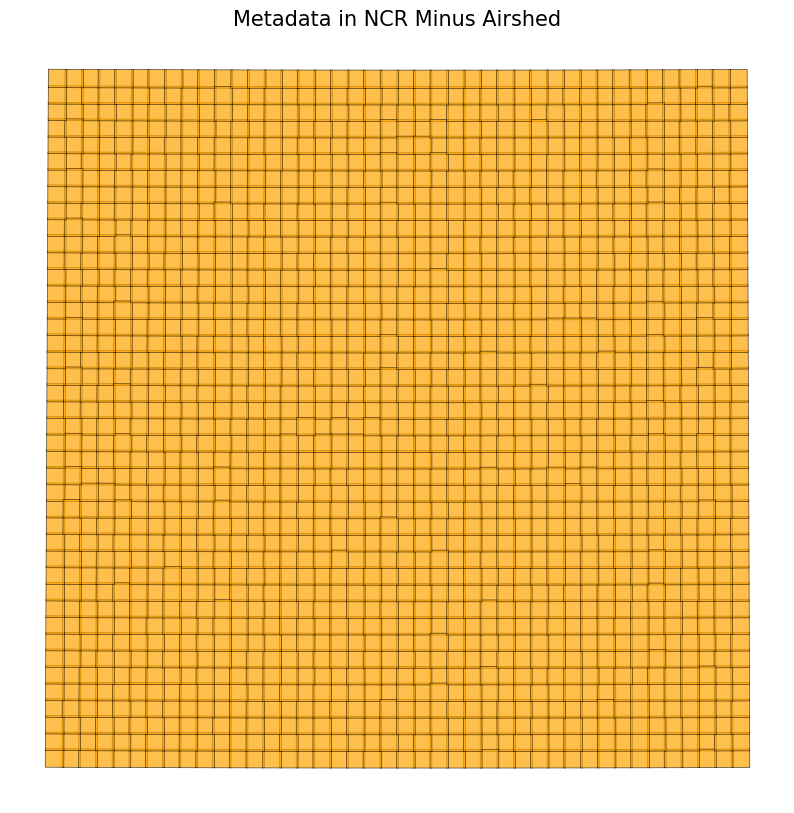

In [73]:
import geopandas as gpd
import matplotlib.pyplot as plt

meta_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data_setup/metadata_lucknow_airshed_100.geojson"

gdf = gpd.read_file(meta_path)
print(gdf.head())
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, color="orange", edgecolor="black", alpha=0.7, linewidth=0.5, markersize=8)
ax.set_title("Metadata in NCR Minus Airshed", fontsize=15)
ax.set_axis_off()
plt.show()


In [108]:
import geopandas as gpd
import os

# Paths
meta_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data_setup/up_metadata_excluding_lucknow_delhi.geojson"
image_dir = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/india_bangladesh_pakisthan_images/images"
symlink_dir = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/uttar_pradesh_pool_data/images"
os.makedirs(symlink_dir, exist_ok=True)

# Read metadata
gdf = gpd.read_file(meta_path)
print(f"Total images in metadata: {len(gdf)}")
print(gdf.head())
count = 0
for idx, row in gdf.iterrows():
    img_name = f"{int(row['x_left'])}_{int(row['y_left'])}.tif"
    src = os.path.join(image_dir, img_name)
    dst = os.path.join(symlink_dir, img_name)
    if os.path.exists(src):
        # Remove any existing symlink or file
        if os.path.exists(dst) or os.path.islink(dst):
            os.remove(dst)
        os.symlink(src, dst)
        count += 1
    else:
        print(f"Image not found: {src}")

print(f"Symlinked {count} images to {symlink_dir}")


Total images in metadata: 34094
   x_idx_left  y_idx_left   x_left   y_left x_idx_right y_idx_right x_right  \
0       40064      162176  8762131  2786585        None        None    None   
1       39488      162176  8759380  2786585        None        None    None   
2       39488      161600  8759380  2789337        None        None    None   
3       40064      161600  8762131  2789337        None        None    None   
4       38912      161600  8756628  2789337        None        None    None   

  y_right region                                           geometry  
0    None   None  POLYGON ((8760603.073 2788114.655, 8763660.554...  
1    None   None  POLYGON ((8757851.34 2788114.655, 8760908.821 ...  
2    None   None  POLYGON ((8757851.34 2790866.388, 8760908.821 ...  
3    None   None  POLYGON ((8760603.073 2790866.388, 8763660.554...  
4    None   None  POLYGON ((8755099.607 2790866.388, 8758157.088...  
Symlinked 34094 images to /home/rishabh.mondal/Brick-Kilns-project/ijcai_

In [109]:
import os
img_dir = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/uttar_pradesh_pool_data/images"
label_src_dir = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/india_bangladesh_pakisthan_images/labels"
label_out_dir = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/uttar_pradesh_pool_data/labels"
os.makedirs(label_out_dir, exist_ok=True)
count = 0
for fname in os.listdir(img_dir):
    if fname.endswith('.tif'):
        basename = os.path.splitext(fname)[0]  # gets x_y part
        labelname = f"{basename}.txt"
        label_src = os.path.join(label_src_dir, labelname)
        label_dst = os.path.join(label_out_dir, labelname)
        if os.path.exists(label_src):
            # Remove existing link/file if any
            if os.path.exists(label_dst) or os.path.islink(label_dst):
                os.remove(label_dst)
            os.symlink(label_src, label_dst)
            count += 1
        else:
            print(f"Label not found for {fname}")

print(f"Symlinked {count} label files to {label_out_dir}")


Label not found for 8858442_3034241.tif
Label not found for 9007036_3240621.tif
Label not found for 8803407_3229614.tif
Label not found for 9161133_2959945.tif
Label not found for 9051063_3259883.tif
Label not found for 8924484_3149814.tif
Label not found for 9136367_3081021.tif
Label not found for 8811663_3083773.tif
Label not found for 8731862_3292904.tif
Label not found for 9122608_2893903.tif
Label not found for 9128112_2866386.tif
Label not found for 8762131_3248877.tif
Label not found for 8836428_2940682.tif
Label not found for 9238181_2803096.tif
Label not found for 8822669_3036993.tif
Label not found for 9081332_2932427.tif
Label not found for 8740117_3413981.tif
Label not found for 8952001_3265387.tif
Label not found for 8940994_3185587.tif
Label not found for 8924484_3009476.tif
Label not found for 8927235_3273642.tif
Label not found for 9086836_3042497.tif
Label not found for 8899718_3298408.tif
Label not found for 8764883_3298408.tif
Label not found for 8817166_3067262.tif


In [110]:
import os

label_dir = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/uttar_pradesh_pool_data/labels"
# delhi_airshed_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/delhi_airshed/labels"
# Assuming classes are 0, 1, 2
class_counts = {0: 0, 1: 0, 2: 0}

for fname in os.listdir(label_dir):
    if fname.endswith('.txt'):
        with open(os.path.join(label_dir, fname), 'r') as f:
            for line in f:
                if line.strip() == "":
                    continue
                class_id = int(line.strip().split()[0])
                if class_id in class_counts:
                    class_counts[class_id] += 1
                else:
                    class_counts[class_id] = 1  # In case of unexpected class

print("Instance counts per class:")
for class_id, count in class_counts.items():
    print(f"Class {class_id}: {count}")


Instance counts per class:
Class 0: 1723
Class 1: 11162
Class 2: 4611


In [113]:
import os

label_dir1 = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/uttar_pradesh_pool_data/images"
label_dir2 = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/ncr_minus_airshed/images"

# Get sets of label filenames (just the filenames, not full path)
files1 = set(f for f in os.listdir(label_dir1) if f.endswith('.tif'))
files2 = set(f for f in os.listdir(label_dir2) if f.endswith('.tif'))

# Find intersection
common_files = files1 & files2

if common_files:
    print(f"Found {len(common_files)} common label files:")
    for fname in sorted(common_files):
        print(fname)
else:
    print("No common label files found.")


No common label files found.


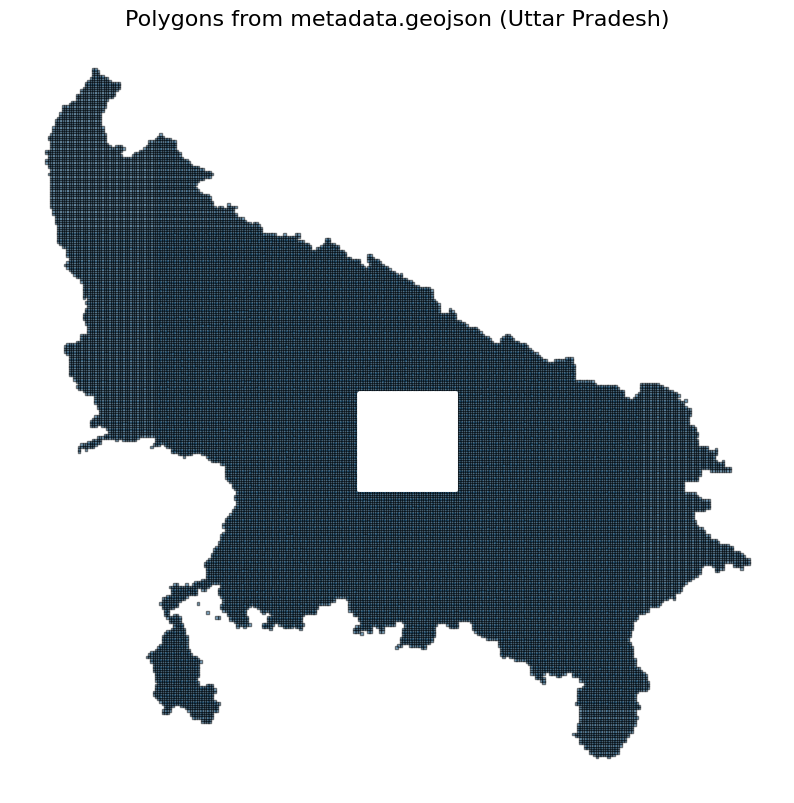

In [82]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Path to your geojson file
geojson_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/india/uttar_pradesh/metadata.geojson"
lucknow_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/lucknow_airshed_100/metadata_lucknow_airshed_100.geojson"

# Read the geojson file
gdf = gpd.read_file(geojson_path)
gdf_lucknow = gpd.read_file(lucknow_path)
if gdf.crs != gdf_lucknow.crs:
    gdf_lucknow = gdf_lucknow.to_crs(gdf.crs)

# Print info to check if it loaded correctly
# print(gdf.head())

# Plot the polygons
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, edgecolor='black', alpha=0.5)
gdf_lucknow.plot(ax=ax, facecolor='white', edgecolor='white', linewidth=2, alpha=1.0)

# Make plot look nice
ax.set_title('Polygons from metadata.geojson (Uttar Pradesh)', fontsize=16)
ax.set_axis_off()

plt.show()


/tmp/ipykernel_2025205/3039577031.py:41: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/tmp/ipykernel_2025205/3039577031.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


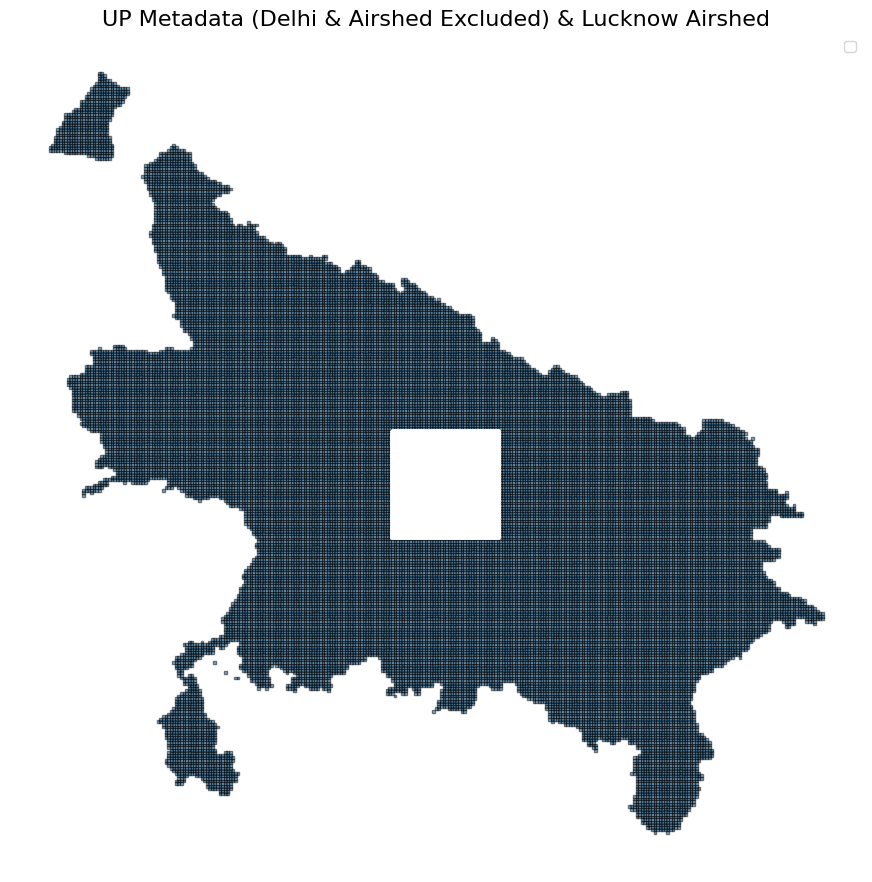

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
# Paths
geojson_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/india/uttar_pradesh/metadata.geojson"
lucknow_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/lucknow_airshed_100/metadata_lucknow_airshed_100.geojson"
delhi_airshed_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/delhi_airshed/metadata.geojson"
delhi_meta_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/ncr_minus_airshed/metadata_in_ncr_minus_airshed.geojson"

# Read geojson files
gdf = gpd.read_file(geojson_path)
gdf_lucknow = gpd.read_file(lucknow_path)
gdf_delhi_airshed = gpd.read_file(delhi_airshed_path)
gdf_delhi = gpd.read_file(delhi_meta_path)

# Ensure CRS match
if gdf.crs != gdf_lucknow.crs:
    gdf_lucknow = gdf_lucknow.to_crs(gdf.crs)
if gdf.crs != gdf_delhi.crs:
    gdf_delhi = gdf_delhi.to_crs(gdf.crs)
if gdf.crs != gdf_delhi_airshed.crs:
    gdf_delhi_airshed = gdf_delhi_airshed.to_crs(gdf.crs)

# Combine delhi & delhi airshed metadata for exclusion
gdf_exclude = gpd.GeoDataFrame(
    pd.concat([gdf_delhi, gdf_delhi_airshed], ignore_index=True),
    crs=gdf.crs
)

# Exclude both via spatial anti-join
sjoined = gpd.sjoin(gdf, gdf_exclude, how='left', predicate='intersects')
gdf_up_excluding_both = sjoined[sjoined['index_right'].isna()].drop(columns=['index_right'])

# Plot
fig, ax = plt.subplots(figsize=(11, 11))
gdf_up_excluding_both.plot(ax=ax, edgecolor='black', alpha=0.5, label="UP (Delhi & Airshed excluded)")
gdf_lucknow.plot(ax=ax, facecolor='white', edgecolor='white', linewidth=2, alpha=1.0, label="Lucknow Airshed")

ax.set_title('UP Metadata (Delhi & Airshed Excluded) & Lucknow Airshed', fontsize=16)
ax.set_axis_off()
ax.legend()
plt.show()


In [101]:
len(gdf_up_excluding_both)
# Save the result to a new GeoJSON file
gdf_up_excluding_both.to_file("uttar_pradesh_except_delhi_and_airshed.geojson", driver='GeoJSON')



In [100]:
gdf_up_excluding_both

,x_idx_left,y_idx_left,x_left,y_left,geometry,x_idx_right,y_idx_right,x_right,y_right,region
0,40064,162176,8762131,2786585,"POLYGON ((8760603.073 2788114.655, 8763660.554...",NaN,NaN,NaN,NaN,NaN
1,39488,162176,8759380,2786585,"POLYGON ((8757851.34 2788114.655, 8760908.821 ...",NaN,NaN,NaN,NaN,NaN
2,39488,161600,8759380,2789337,"POLYGON ((8757851.34 2790866.388, 8760908.821 ...",NaN,NaN,NaN,NaN,NaN
3,40064,161600,8762131,2789337,"POLYGON ((8760603.073 2790866.388, 8763660.554...",NaN,NaN,NaN,NaN,NaN
4,38912,161600,8756628,2789337,"POLYGON ((8755099.607 2790866.388, 8758157.088...",NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
38818,89024,52736,8996029,3309415,"POLYGON ((8994500.38 3310943.928, 8997557.861 ...",NaN,NaN,NaN,NaN,NaN
38819,88448,52736,8993277,3309415,"POLYGON ((8991748.647 3310943.928, 8994806.128...",NaN,NaN,NaN,NaN,NaN
38820,89600,52736,8998780,3309415,"POLYGON ((8997252.113 3310943.928, 9000309.594...",NaN,NaN,NaN,NaN,NaN
38821,89024,52160,8996029,3312166,"POLYGON ((8994500.38 3313695.661, 8997557.861 ...",NaN,NaN,NaN,NaN,NaN


In [105]:
import geopandas as gpd
import pandas as pd

# Paths
geojson_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/india/uttar_pradesh/metadata.geojson"
lucknow_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/lucknow_airshed_100/metadata_lucknow_airshed_100.geojson"
delhi_airshed_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/delhi_airshed/metadata.geojson"
delhi_meta_path = "/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/ncr_minus_airshed/metadata_in_ncr_minus_airshed.geojson"

# Read geojson files
gdf_up = gpd.read_file(geojson_path)
gdf_lucknow = gpd.read_file(lucknow_path)
gdf_delhi_airshed = gpd.read_file(delhi_airshed_path)
gdf_delhi = gpd.read_file(delhi_meta_path)

# Ensure CRS match
if gdf_up.crs != gdf_lucknow.crs:
    gdf_lucknow = gdf_lucknow.to_crs(gdf_up.crs)
if gdf_up.crs != gdf_delhi_airshed.crs:
    gdf_delhi_airshed = gdf_delhi_airshed.to_crs(gdf_up.crs)
if gdf_up.crs != gdf_delhi.crs:
    gdf_delhi = gdf_delhi.to_crs(gdf_up.crs)

# Combine all regions to exclude
gdf_exclude = gpd.GeoDataFrame(
    pd.concat([gdf_lucknow, gdf_delhi, gdf_delhi_airshed], ignore_index=True),
    crs=gdf_up.crs
)

# Exclude (anti-join): keep only UP metadata NOT intersecting any excluded regions
sjoined = gpd.sjoin(gdf_up, gdf_exclude, how='left', predicate='intersects')
gdf_up_excluding_all = sjoined[sjoined['index_right'].isna()].drop(columns=['index_right'])

# Save result
gdf_up_excluding_all.to_file("up_metadata_excluding_lucknow_delhi.geojson", driver="GeoJSON")
print(f"Saved {len(gdf_up_excluding_all)} metadata patches to up_metadata_excluding_lucknow_delhi.geojson")


Saved 34094 metadata patches to up_metadata_excluding_lucknow_delhi.geojson


   x_idx_left  y_idx_left   x_left   y_left x_idx_right y_idx_right x_right  \
0       40064      162176  8762131  2786585        None        None    None   
1       39488      162176  8759380  2786585        None        None    None   
2       39488      161600  8759380  2789337        None        None    None   
3       40064      161600  8762131  2789337        None        None    None   
4       38912      161600  8756628  2789337        None        None    None   

  y_right region                                           geometry  
0    None   None  POLYGON ((8760603.073 2788114.655, 8763660.554...  
1    None   None  POLYGON ((8757851.34 2788114.655, 8760908.821 ...  
2    None   None  POLYGON ((8757851.34 2790866.388, 8760908.821 ...  
3    None   None  POLYGON ((8760603.073 2790866.388, 8763660.554...  
4    None   None  POLYGON ((8755099.607 2790866.388, 8758157.088...  
Loaded 34094 metadata patches from /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_exper

/tmp/ipykernel_2025205/794775689.py:10: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
/tmp/ipykernel_2025205/794775689.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


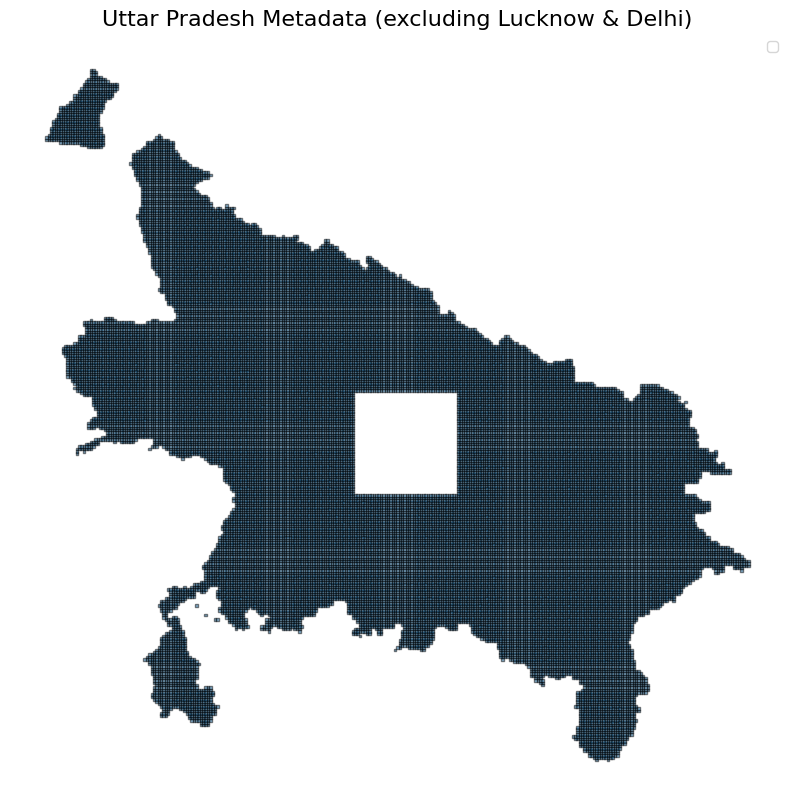

In [107]:
path="/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data_setup/up_metadata_excluding_lucknow_delhi.geojson"
gdf_up_excluding_all = gpd.read_file(path)
print(gdf_up_excluding_all.head())
print(f"Loaded {len(gdf_up_excluding_all)} metadata patches from {path}")
# Plot to verify
fig, ax = plt.subplots(figsize=(10, 10))
gdf_up_excluding_all.plot(ax=ax, edgecolor='black', alpha=0.5, label="UP Metadata (excluding Lucknow & Delhi)")
ax.set_title('Uttar Pradesh Metadata (excluding Lucknow & Delhi)', fontsize=16)
ax.set_axis_off()
plt.legend()
plt.show()

In [116]:
import os
region="delhi_airshed"
# Paths
image_dir = f"/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/lucknow_airshed_100/images"
label_dir_yolo = f"/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/lucknow_airshed_100/labels"
label_dir_voc = f"/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/data/lucknow_airshed_100/labels_voc"

# Create output directory if not exists
os.makedirs(label_dir_voc, exist_ok=True)

# Process each label file
for fname in os.listdir(label_dir_yolo):
    if not fname.endswith('.txt'):
        continue

    label_path = os.path.join(label_dir_yolo, fname)
    image_path = os.path.join(image_dir, fname.replace(".txt", ".tif"))

    if not os.path.exists(image_path):
        continue

    # Get image dimensions
    from PIL import Image
    img = Image.open(image_path)
    w, h = img.size

    pascal_boxes = []

    with open(label_path, 'r') as f:
        for line in f:
            parts = list(map(float, line.strip().split()))
            if len(parts) != 9:
                continue
            cls = int(parts[0])
            coords = parts[1:]
            x_coords = coords[::2]
            y_coords = coords[1::2]
            x_min, x_max = min(x_coords), max(x_coords)
            y_min, y_max = min(y_coords), max(y_coords)
            # Clip to image size
            x_min = max(0, min(x_min * w, w))
            x_max = max(0, min(x_max * w, w))
            y_min = max(0, min(y_min * h, h))
            y_max = max(0, min(y_max * h, h))
            pascal_boxes.append([cls, x_min, y_min, x_max, y_max])

    # Save in Pascal VOC format: cls x_min y_min x_max y_max
    output_path = os.path.join(label_dir_voc, fname)
    with open(output_path, 'w') as f_out:
        for box in pascal_boxes:
            f_out.write(f"{int(box[0])} {box[1]:.2f} {box[2]:.2f} {box[3]:.2f} {box[4]:.2f}\n")

# label_dir_voc